<a href="https://colab.research.google.com/github/sahanyafernando/EN3150-A03-edge-cnn/blob/main/notebooks/00_shared_data_and_final_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00 — Shared Data and Final Comparison

**EN3150 Assignment 03 — Resource-Constrained CNN for Edge Image Classification**  
**Owner:** Sahanya  
**Environment:** Google Colab + TensorFlow/Keras

## Purpose
Use the first half now to verify the common dataset. Use the final-comparison half only after the four model result JSON files exist.

In [5]:
# TensorFlow is already available in Google Colab.
# We only install the extra evaluation package used later.
%pip install -q scikit-learn

In [6]:
import os
import gc
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
SEED=42
IMG_SIZE=64
BATCH_SIZE=64
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(SEED,IMG_SIZE,BATCH_SIZE)

42 64 64


In [8]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/EN3150_A03")

DATA_ROOT = PROJECT_ROOT / "dataset_cache"
TFDS_ROOT = DATA_ROOT  # compatibility alias; TFDS is not used anymore
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts"
RESULT_ROOT = PROJECT_ROOT / "shared_results"
PLOT_ROOT = PROJECT_ROOT / "plots"

for p in [DATA_ROOT, ARTIFACT_ROOT, RESULT_ROOT, PLOT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset cache:", DATA_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/EN3150_A03
Dataset cache: /content/drive/MyDrive/EN3150_A03/dataset_cache


## 1. Shared data preparation

### Dataset loader update

This notebook intentionally **does not use `tensorflow_datasets` / `tfds.load()`**.

Some Colab runtimes were importing a `tensorflow_datasets` installation where
`tfds.load` was unavailable. To make the group notebook more reliable, the
dataset is now downloaded directly from TensorFlow's official `flower_photos`
archive and split deterministically using `SEED = 42`.

The project still uses the same **TF Flowers dataset**, **64×64 images**, and
**70% / 15% / 15% split**.

In [11]:
# ============================================================
# TF FLOWERS DATASET — robust loader without tensorflow_datasets
# ============================================================

# Official TensorFlow Flowers dataset
DATASET_URL = (
    "https://storage.googleapis.com/download.tensorflow.org/"
    "example_images/flower_photos.tgz"
)

# Expected flower classes
EXPECTED_CLASSES = {
    "daisy",
    "dandelion",
    "roses",
    "sunflowers",
    "tulips",
}

# ------------------------------------------------------------
# Download and extract dataset
# ------------------------------------------------------------
archive_path = keras.utils.get_file(
    fname="flower_photos.tgz",
    origin=DATASET_URL,
    extract=True,
    cache_dir=str(DATA_ROOT),
    cache_subdir="downloads",
)

archive_path = Path(archive_path)

# Start searching from the folder where Keras extracted the archive
search_root = archive_path.parent

# ------------------------------------------------------------
# Find the actual directory containing the five class folders
# ------------------------------------------------------------
DATA_DIR = None

candidate_dirs = [search_root]

candidate_dirs.extend(
    p
    for p in search_root.rglob("*")
    if p.is_dir()
)

for candidate in candidate_dirs:

    try:
        child_dirs = {
            p.name
            for p in candidate.iterdir()
            if p.is_dir()
        }

    except PermissionError:
        continue

    # Correct dataset directory must contain all five flower classes
    if EXPECTED_CLASSES.issubset(child_dirs):
        DATA_DIR = candidate
        break


if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the extracted TF Flowers class folders. "
        f"Searched inside: {search_root}"
    )


print("Dataset directory:", DATA_DIR)


# ------------------------------------------------------------
# Class information
# ------------------------------------------------------------
CLASS_NAMES = sorted(EXPECTED_CLASSES)

NUM_CLASSES = len(CLASS_NAMES)

class_to_index = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}


# ------------------------------------------------------------
# Collect image paths and labels
# ------------------------------------------------------------
all_paths = []
all_labels = []

valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png"
}


for class_name in CLASS_NAMES:

    class_dir = DATA_DIR / class_name

    for image_path in sorted(class_dir.rglob("*")):

        if (
            image_path.is_file()
            and image_path.suffix.lower() in valid_extensions
        ):

            all_paths.append(str(image_path))

            all_labels.append(
                class_to_index[class_name]
            )


# Important: force paths to string type
all_paths = np.asarray(
    all_paths,
    dtype=str
)

all_labels = np.asarray(
    all_labels,
    dtype=np.int32
)


print("Classes:", CLASS_NAMES)
print("Total images:", len(all_paths))


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
assert len(all_paths) > 0, (
    "No flower images were found. "
    "Please check the extracted dataset directory."
)

assert NUM_CLASSES == 5


# ------------------------------------------------------------
# Deterministic 70 / 15 / 15 split
# ------------------------------------------------------------
rng = np.random.default_rng(SEED)

indices = np.arange(
    len(all_paths)
)

rng.shuffle(indices)


all_paths = all_paths[indices]
all_labels = all_labels[indices]


n_total = len(all_paths)

n_train = int(
    n_total * 0.70
)

n_val = int(
    n_total * 0.15
)


# Training set
train_paths = all_paths[
    :n_train
]

train_labels = all_labels[
    :n_train
]


# Validation set
val_paths = all_paths[
    n_train:n_train + n_val
]

val_labels = all_labels[
    n_train:n_train + n_val
]


# Test set
test_paths = all_paths[
    n_train + n_val:
]

test_labels = all_labels[
    n_train + n_val:
]


# ------------------------------------------------------------
# Function to read images
# ------------------------------------------------------------
def decode_image(path, label):

    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_jpeg(
        image_bytes,
        channels=3,
        try_recover_truncated=True,
    )

    return image, label


# ------------------------------------------------------------
# Create TensorFlow datasets
# ------------------------------------------------------------
raw_train = (
    tf.data.Dataset
    .from_tensor_slices(
        (train_paths, train_labels)
    )
    .map(
        decode_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
)


raw_val = (
    tf.data.Dataset
    .from_tensor_slices(
        (val_paths, val_labels)
    )
    .map(
        decode_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
)


raw_test = (
    tf.data.Dataset
    .from_tensor_slices(
        (test_paths, test_labels)
    )
    .map(
        decode_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
)


# ------------------------------------------------------------
# Count samples
# ------------------------------------------------------------
def count_examples(ds):

    return int(
        tf.data.experimental
        .cardinality(ds)
        .numpy()
    )


print(
    "Train:",
    count_examples(raw_train)
)

print(
    "Validation:",
    count_examples(raw_val)
)

print(
    "Test:",
    count_examples(raw_test)
)


# ------------------------------------------------------------
# Final safety check
# ------------------------------------------------------------
assert (
    count_examples(raw_train)
    + count_examples(raw_val)
    + count_examples(raw_test)
    == n_total
)


print("Dataset loaded successfully.")

Dataset directory: /content/drive/MyDrive/EN3150_A03/dataset_cache/downloads/flower_photos_extracted/flower_photos
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Total images: 3670
Train: 2569
Validation: 550
Test: 551
Dataset loaded successfully.


In [12]:
AUTOTUNE=tf.data.AUTOTUNE
def preprocess(image,label):
    image=tf.image.resize(image,[IMG_SIZE,IMG_SIZE],antialias=True)
    return tf.cast(image,tf.float32),label
train_ds=(raw_train.shuffle(2048,seed=SEED,reshuffle_each_iteration=True).map(preprocess,num_parallel_calls=AUTOTUNE).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE))
val_ds=(raw_val.map(preprocess,num_parallel_calls=AUTOTUNE).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE))
test_ds=(raw_test.map(preprocess,num_parallel_calls=AUTOTUNE).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE))

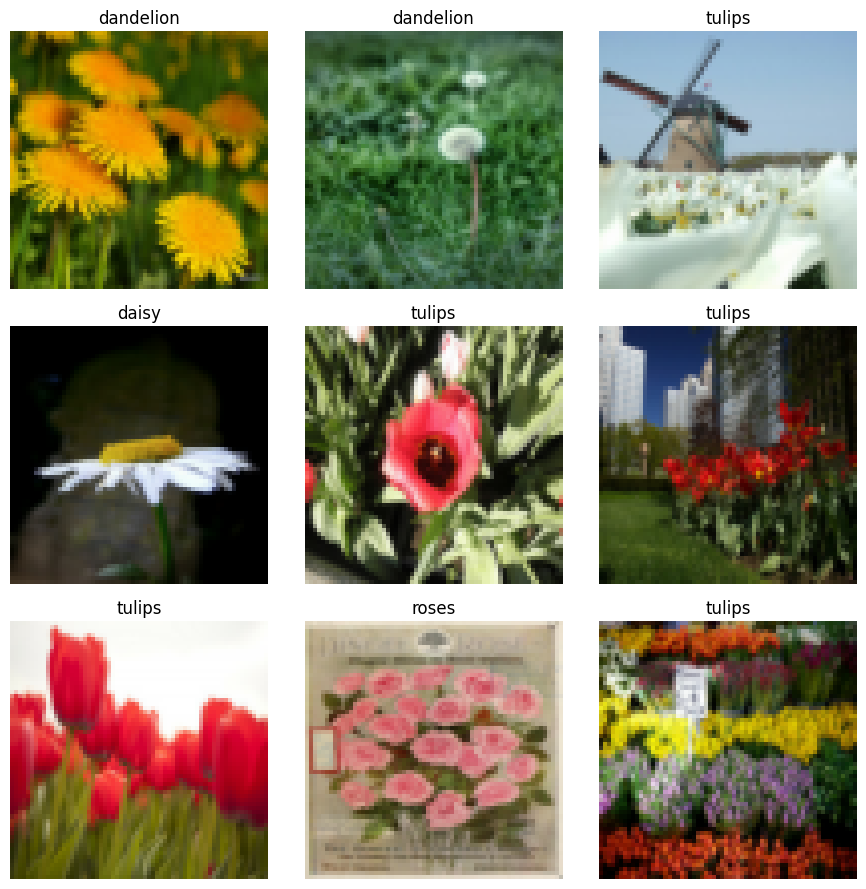

In [13]:
plt.figure(figsize=(9,9))
for images,labels in train_ds.take(1):
    for i in range(min(9,len(images))):
        plt.subplot(3,3,i+1); plt.imshow(tf.cast(images[i],tf.uint8)); plt.title(CLASS_NAMES[int(labels[i])]); plt.axis('off')
plt.tight_layout(); plt.savefig(PLOT_ROOT/'dataset_examples_64x64.png',dpi=180); plt.show()

In [14]:
dataset_summary = {
    "dataset": "TF Flowers / flower_photos",
    "dataset_url": DATASET_URL,
    "image_size": [64, 64, 3],
    "split": {
        "train": "70%",
        "validation": "15%",
        "test": "15%",
    },
    "seed": SEED,
    "classes": CLASS_NAMES,
    "train_samples": count_examples(raw_train),
    "validation_samples": count_examples(raw_val),
    "test_samples": count_examples(raw_test),
}

with open(RESULT_ROOT / "dataset_summary.json", "w") as f:
    json.dump(dataset_summary, f, indent=2)

print(json.dumps(dataset_summary, indent=2))

{
  "dataset": "TF Flowers / flower_photos",
  "dataset_url": "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
  "image_size": [
    64,
    64,
    3
  ],
  "split": {
    "train": "70%",
    "validation": "15%",
    "test": "15%"
  },
  "seed": 42,
  "classes": [
    "daisy",
    "dandelion",
    "roses",
    "sunflowers",
    "tulips"
  ],
  "train_samples": 2569,
  "validation_samples": 550,
  "test_samples": 551
}


---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
feat: add shared TF Flowers data preparation and split verification
```
File:
```text
notebooks/00_shared_data_and_final_comparison.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.

# STOP HERE until training is complete
Later this notebook expects `model_a.json`, `model_b.json`, `mobilenetv2.json`, and `efficientnetb0.json` in `MyDrive/EN3150_A03/shared_results/`.

## 2. Final comparison

In [ ]:
required=['model_a.json','model_b.json','mobilenetv2.json','efficientnetb0.json']
missing=[x for x in required if not (RESULT_ROOT/x).exists()]
if missing: raise FileNotFoundError('Missing: '+', '.join(missing))
records=[json.load(open(RESULT_ROOT/x)) for x in required]
comparison=pd.DataFrame(records)
display(comparison)
comparison.to_csv(RESULT_ROOT/'final_model_comparison.csv',index=False)

In [ ]:
plt.figure(figsize=(8,5)); plt.scatter(comparison.model_size_mb,comparison.accuracy,s=80)
for _,r in comparison.iterrows(): plt.annotate(r.model,(r.model_size_mb,r.accuracy),xytext=(5,5),textcoords='offset points')
plt.xlabel('Saved model size (MB)'); plt.ylabel('Test accuracy'); plt.title('Accuracy vs Model Size'); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(PLOT_ROOT/'final_accuracy_vs_model_size.png',dpi=180); plt.show()

In [ ]:
plt.figure(figsize=(8,5)); plt.scatter(comparison.parameters,comparison.accuracy,s=80)
for _,r in comparison.iterrows(): plt.annotate(r.model,(r.parameters,r.accuracy),xytext=(5,5),textcoords='offset points')
plt.xscale('log'); plt.xlabel('Parameters (log scale)'); plt.ylabel('Test accuracy'); plt.title('Accuracy vs Parameter Count'); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(PLOT_ROOT/'final_accuracy_vs_parameters.png',dpi=180); plt.show()

## Report discussion
Use the measured table to discuss accuracy, memory footprint, computational cost, Model A vs Model B, and custom Model B vs MobileNetV2/EfficientNetB0. Do not decide the conclusion before results exist.

---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
analysis: add final accuracy memory and computational cost comparison
```
File:
```text
notebooks/00_shared_data_and_final_comparison.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.